- E01: I did not get around to seeing what happens when you initialize all weights and biases to zero. Try this and train the neural net. You might think either that 1) the network trains just fine or 2) the network doesn't train at all, but actually it is 3) the network trains but only partially, and achieves a pretty bad final performance. Inspect the gradients and activations to figure out what is happening and why the network is only partially training, and what part is being trained exactly.
- E02: BatchNorm, unlike other normalization layers like LayerNorm/GroupNorm etc. has the big advantage that after training, the batchnorm gamma/beta can be "folded into" the weights of the preceeding Linear layers, effectively erasing the need to forward it at test time. Set up a small 3-layer MLP with batchnorms, train the network, then "fold" the batchnorm gamma/beta into the preceeding Linear layer's W,b by creating a new W2, b2 and erasing the batch norm. Verify that this gives the same forward pass during inference. i.e. we see that the batchnorm is there just for stabilizing the training, and can be thrown out after training is done! pretty cool.

In [111]:
import torch
import random
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [75]:
# 训练集处理

In [81]:
words = open('../names.txt', 'r').read().splitlines()

chs = sorted(list(set(''.join(words))))
sti = { s:i for i, s in enumerate(chs) }
sti['.'] = 0
its = { i:s for s, i in sti.items()}

block_size = 3

In [149]:
def build_dataset(wordset):
    X,Y = [], []
    for w in wordset:
        contex = [0]*block_size
        for ch in w:
            ix = sti[ch]
            X.append(contex)
            Y.append(ix)
            contex = contex[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

random.shuffle(words)
n_tr = int(len(words) * 0.8)
n_dev = int(len(words) * 0.9)

Xtr, Ytr = build_dataset(words[:n_tr])
Xdev, Ydev = build_dataset(words[n_tr:n_dev])
Xtes, Ytes = build_dataset(words[n_dev:])

In [355]:
class Linear:

    def __init__(self, in_fan, out_fan, bias = True):
        self.weight = torch.randn((in_fan, out_fan)) #/ (in_fan ** 0.5)
        self.bias = torch.zeros(out_fan) if bias else None
        self.hasbias = bias

    def __call__(self, x):
        self.out = x @ self.weight
        if (self.hasbias):
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight, self.bias]

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

class BatchNorm1d:
    # 对 miniBatch 中的每一批数据做normal
    def __init__(self, num_features, eps = 1e-5, momentum = 0.1):
        self.traning = True
        self.eps = eps
        self.momentum = momentum
        self.gamma = torch.ones(num_features)
        self.beta = torch.zeros(num_features)
        self.running_mean = torch.zeros(num_features)
        self.running_var = torch.zeros(num_features)

    def __call__(self, x):
        if (self.traning):
            xmean = x.mean(0, keepdim=True)
            xvar = x.var(0, keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / (xvar + self.eps)**0.5
        self.out = xhat * self.gamma + self.beta
        # update running mean and var
        if (self.traning):
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar

        return self.out

    def parameters(self):
        return [self.gamma, self.beta]

In [327]:
vocab_size = len(sti)
n_embd = 10
n_hidden = 200
C = torch.randn(vocab_size, n_embd)

In [356]:
# init by my layer
def initMyLayer():
    # layers = [
    #     Linear(n_embd * block_size, n_hidden), Tanh(),
    #     Linear(n_hidden, n_hidden), Tanh(),
    #     Linear(n_hidden, n_hidden), Tanh(),
    #     Linear(n_hidden, n_hidden), Tanh(),
    #     Linear(n_hidden, vocab_size)
    #     ]

    layers = [
        Linear(n_embd * block_size, n_hidden), BatchNorm1d(n_hidden), Tanh(),
        Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
        Linear(n_hidden, vocab_size), BatchNorm1d(vocab_size)
    ]

    parameters = [C] + [p for Layer in layers for p in Layer.parameters()]
    num = sum(p.nelement() for p in parameters)
    print(num)
    for p in parameters:
        p.requires_grad = True

    with torch.no_grad():
        layers[-1].gamma *= 0.1
        for layer in layers:
            if isinstance(layer, Linear):
                layer.weight *= 5/3

    return layers, parameters

layers, parameters = initMyLayer()

52951


In [208]:
# init use torch
def initTorchLayer():
    layers = [
                # nn.Linear(n_embd * block_size, n_hidden), nn.BatchNorm1d(n_hidden) ,nn.Tanh(),
                nn.Linear(n_embd * block_size, n_hidden), nn.Tanh(),
                nn.Linear(n_hidden, vocab_size)
            ]

    parameters = [C] + [p for layer in layers for p in layer.parameters()]
    num = sum(p.nelement() for p in parameters)
    print(num)
    for p in parameters:
        p.requires_grad = True

    return layers, parameters

layers, parameters = initTorchLayer()

11897


In [357]:
# Train loop
step_count = 200000
lossi = []
ud = []

for i in range(step_count):
    # minbatch
    ix = torch.randint(0, Xtr.shape[0], (32,))
    emb = C[Xtr[ix]].view(-1, n_embd * block_size)
    x = emb
    for layer in layers:
        x = layer(x)

    loss = F.cross_entropy(x, Ytr[ix])

    for layer in layers:
        layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i %  10000 == 0:
        print(f'turn {i} loss = {loss.item()}')

    lossi.append(loss.item())
    with torch.no_grad():
        ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

    # if (i > 1000):
    #     break


turn 0 loss = 3.311445474624634
turn 10000 loss = 2.4384498596191406
turn 20000 loss = 2.2175567150115967
turn 30000 loss = 2.3599050045013428
turn 40000 loss = 2.407172441482544
turn 50000 loss = 2.7627878189086914
turn 60000 loss = 2.4095747470855713
turn 70000 loss = 2.2950596809387207
turn 80000 loss = 2.2567672729492188
turn 90000 loss = 2.363253116607666
turn 100000 loss = 2.1471707820892334
turn 110000 loss = 2.6118147373199463
turn 120000 loss = 2.254659414291382
turn 130000 loss = 2.42999529838562
turn 140000 loss = 2.114258050918579
turn 150000 loss = 2.0931379795074463
turn 160000 loss = 2.1017262935638428
turn 170000 loss = 2.5230438709259033
turn 180000 loss = 2.4492716789245605
turn 190000 loss = 2.1927034854888916


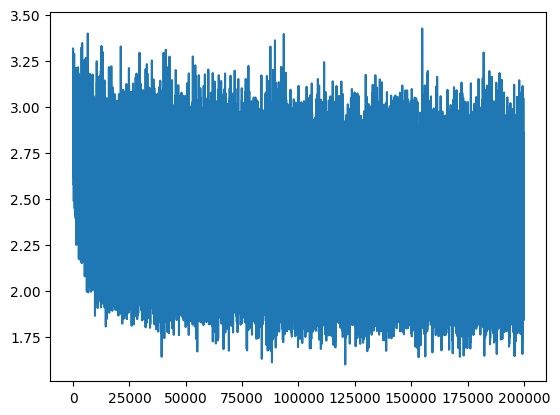

In [330]:
plt.plot(lossi)

layer 2 (      Tanh): mean -0.01, std 0.63, saturated: 5.41%
layer 5 (      Tanh): mean +0.01, std 0.65, saturated: 9.39%


Text(0.5, 1.0, 'activation distribution')

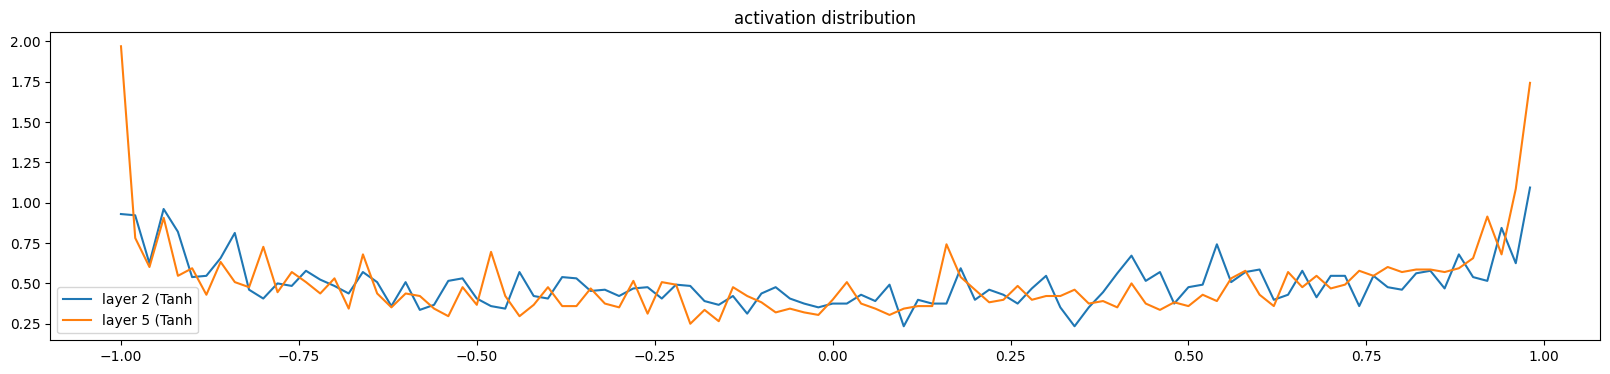

In [331]:
# tanh saturated
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers): # note: exclude the output layer
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

layer 2 (      Tanh): mean +0.000000, std 4.853445e-03
layer 5 (      Tanh): mean +0.000000, std 4.128782e-03


Text(0.5, 1.0, 'gradient distribution')

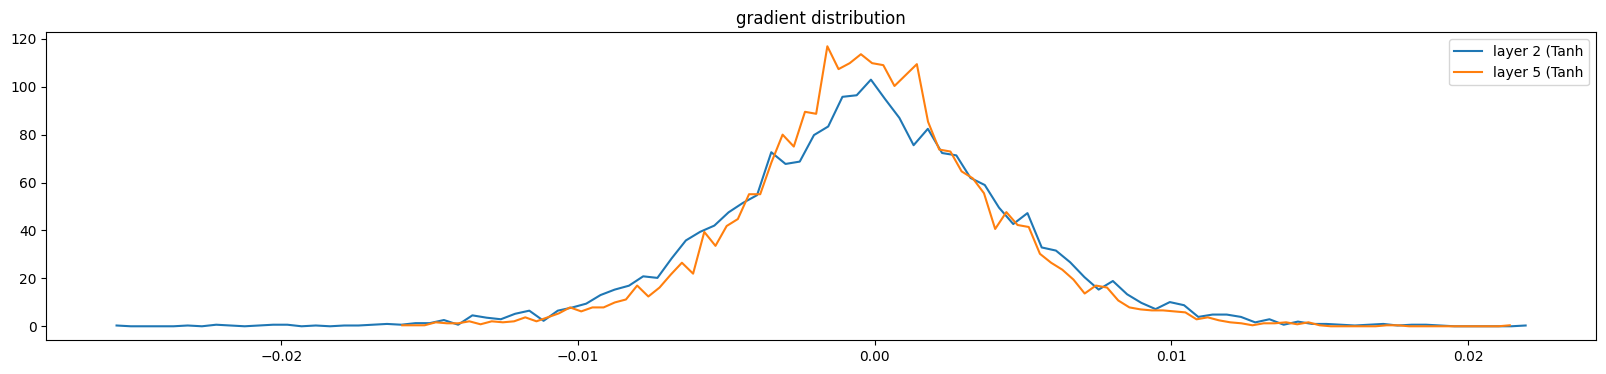

In [332]:
# tanh grad
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

weight   (27, 10) | mean +0.000000 | std 1.022038e-02 | grad:data ratio 9.239239e-03
weight  (30, 200) | mean -0.000004 | std 1.642312e-03 | grad:data ratio 9.830209e-04
weight (200, 200) | mean +0.000007 | std 5.636165e-04 | grad:data ratio 3.388552e-04
weight  (200, 27) | mean +0.000003 | std 1.370773e-03 | grad:data ratio 8.291264e-04


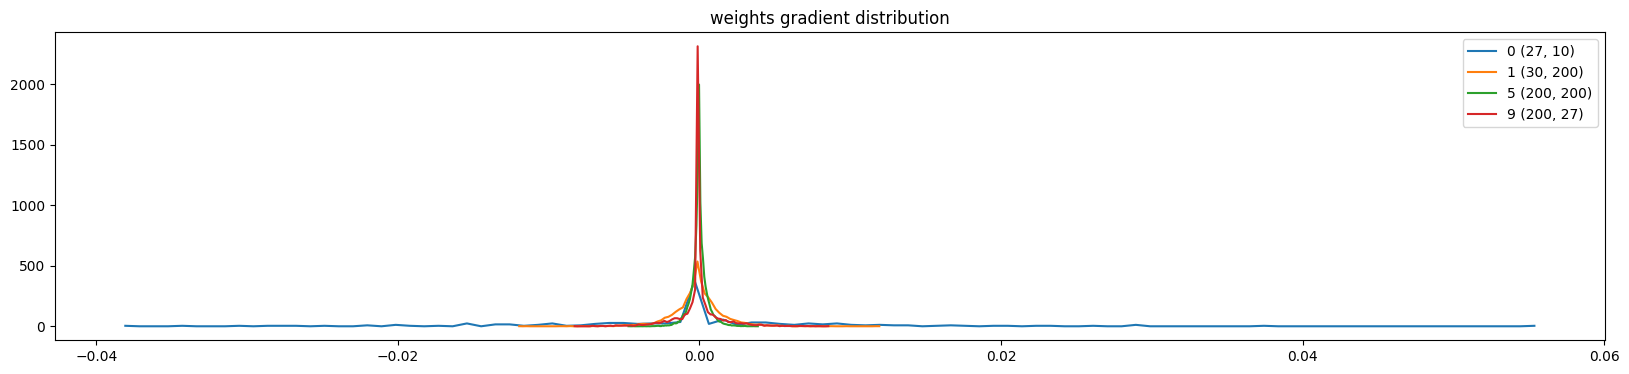

In [333]:
# weights grad
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
    t = p.grad
    if p.ndim == 2:
        print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

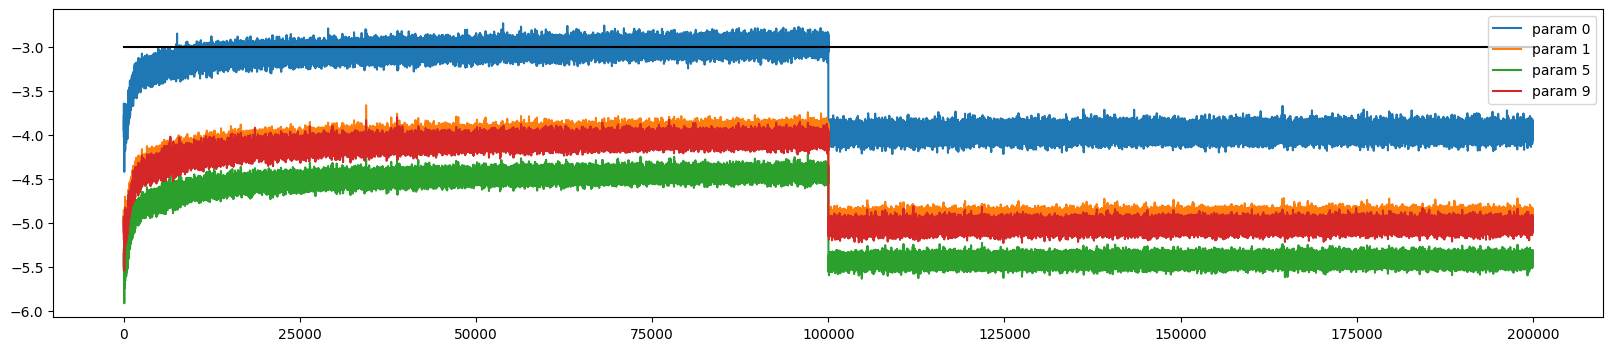

In [334]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);

In [381]:
@torch.no_grad()
def split_loss(X, Y):
    emb = C[X]
    x = emb.view(-1, block_size * n_embd)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Y)
    return loss.item()

for layer in layers:
    layer.training = False

trloss = split_loss(Xtr, Ytr)
devloss = split_loss(Xdev, Ydev)

print('train loss', trloss, 'dev loss', devloss)

train loss 2.274920701980591 dev loss 2.288665533065796


In [ ]:
x# flod in
x
for layer in layers:
    print(type(layer))

<class '__main__.Linear'>
<class '__main__.BatchNorm1d'>
<class '__main__.Tanh'>
<class '__main__.Linear'>
<class '__main__.BatchNorm1d'>
<class '__main__.Tanh'>
<class '__main__.Linear'>
<class '__main__.BatchNorm1d'>


In [382]:
with torch.no_grad():
    foldInlayer = []
    for i in range(3):
        layerindex = i *3
        ll = layers[layerindex]
        bn = layers[layerindex + 1]
        
        if (isinstance(ll, Linear) and isinstance(bn, BatchNorm1d)):
            newll = Linear(ll.weight.shape[0], ll.weight.shape[1])
            newll.weight = ll.weight * bn.gamma / torch.sqrt(bn.running_var)
            newll.bias = bn.gamma*(ll.bias - bn.running_mean)/torch.sqrt(bn.running_var) + bn.beta
            foldInlayer.append(newll)

        if (i != 2):
            foldInlayer.append(Tanh())

In [378]:
foldInlayer

In [383]:
@torch.no_grad()
def split_loss_noBN(X, Y):
    emb = C[X]
    x = emb.view(-1, block_size * n_embd)
    for layer in foldInlayer:
        x = layer(x)
    loss = F.cross_entropy(x, Y)
    return loss.item()

trloss = split_loss_noBN(Xtr, Ytr)
devloss = split_loss_noBN(Xdev, Ydev)

print('train loss', trloss, 'dev loss', devloss)

train loss 2.2752411365509033 dev loss 2.2889058589935303
